# Long-Term Multi-Pattern Strategy Backtest

This notebook backtests the Multi-Pattern Confluence Strategy on any ticker with daily OHLCV data.

**Strategy**: Uses 20 pattern detectors across 4 categories (Basic, Harmonic, Complex, Classic)
with confluence scoring to generate trading signals.

**Data**: Daily OHLCV CSV from `data/raw/{TICKER}_daily.csv` — requires ≥500 trading days.


## Configuration

Set `TICKER` to any symbol for which you have downloaded `{TICKER}_daily.csv` in `data/raw/`.
The CSV must contain columns: `Date, Open, High, Low, Close, Volume` (case-insensitive).


In [1]:
TICKER = "SPY"  # ← Change to any ticker (e.g., 'QQQ', 'GLD', 'BTC_USD')

CONFIG = {
    # Data settings
    "data": {
        "ticker": TICKER,
        "filename": f"{TICKER}_daily.csv",
        "directory": "data/raw",
        "columns": ["Open", "High", "Low", "Close", "Volume"],
    },
    # Backtest settings
    "backtest": {
        "initial_capital": 100000,
        "commission": 0.001,  # 0.1% commission
        "exclusive_orders": True,
    },
    # Strategy parameters - optimized for daily timeframe
    "strategy": {
        "min_confidence": 0.50,
        "min_confluence_count": 1,
        "risk_per_trade": 0.02,
        "max_open_positions": 10,
        "use_regime_filter": True,
    },
    # Benchmark comparison settings
    "benchmark": {
        "risk_free_rate": 0.05,
        "periods_per_year": 252,
    },
    # Risk metrics settings
    "risk": {
        "var_confidence_levels": [0.95, 0.99],
        "rolling_beta_window": 63,
    },
    # Visualization settings
    "visualization": {
        "figure_size": (14, 10),
        "style": "seaborn-v0_8-whitegrid",
        "dpi": 150,
    },
    # Output settings
    "output": {
        "directory": "reports",
        "plot_filename": f"{TICKER.lower()}_backtest_results.html",
    },
}

## 1. Setup and Imports

In [2]:
import sys
from pathlib import Path

# Setup project root
project_root = Path(".").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Import backtesting.py integration
from src.strategies.backtest_py import BacktestPyRunner

# Import visualization

# Import helpers
from src.utils.notebook_helpers import (
    get_data_path,
    get_output_path,
)

# Print configuration
print("=" * 60)
print("Long-Term Backtest Configuration")
print("=" * 60)
print(f"TICKER: {CONFIG['data']['ticker']}")
for section in ["data", "backtest", "strategy", "benchmark", "risk", "visualization", "output"]:
    print(f"{section.upper()}:")
    for key, value in CONFIG[section].items():
        print(f"  {key}: {value}")
print("=" * 60)

Loading BokehJS ...

Long-Term Backtest Configuration
TICKER: SPY
DATA:
  ticker: SPY
  filename: SPY_daily.csv
  directory: data/raw
  columns: ['Open', 'High', 'Low', 'Close', 'Volume']
BACKTEST:
  initial_capital: 100000
  commission: 0.001
  exclusive_orders: True
STRATEGY:
  min_confidence: 0.5
  min_confluence_count: 1
  risk_per_trade: 0.02
  max_open_positions: 10
  use_regime_filter: True
BENCHMARK:
  risk_free_rate: 0.05
  periods_per_year: 252
RISK:
  var_confidence_levels: [0.95, 0.99]
  rolling_beta_window: 63
VISUALIZATION:
  figure_size: (14, 10)
  style: seaborn-v0_8-whitegrid
  dpi: 150
OUTPUT:
  directory: reports
  plot_filename: spy_backtest_results.html


## 2. Load and Prepare Data

In [3]:
# Load daily data for the configured ticker
data_path = get_data_path(CONFIG, project_root)

df = pd.read_csv(data_path, index_col=0, parse_dates=True)

# Ensure required columns with proper casing
df.columns = [c.capitalize() for c in df.columns]

# Display basic info
print("=" * 60)
print(f"{TICKER} Daily Data Summary")
print("=" * 60)
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Total Trading Days: {len(df)}")
print(f"Years of Data: {(df.index.max() - df.index.min()).days / 365.25:.1f}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

SPY Daily Data Summary
Date Range: 2015-01-02 to 2024-12-30
Total Trading Days: 2515
Years of Data: 10.0

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Data shape: (2515, 5)

First 5 rows:


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,170.125015,171.325830,169.089839,170.911759,121465900
2015-01-05,167.052612,169.247181,166.746204,169.081555,169632600
2015-01-06,165.479141,167.880745,164.684120,167.359012,209151400
2015-01-07,167.541199,167.880740,166.356963,166.804154,125346700
2015-01-08,170.514236,170.729561,168.932497,168.949050,147217800


## 2.1 Data Validation

Verifies the CSV meets minimum requirements for a reliable backtest.


In [4]:
REQUIRED_COLS = {"Open", "High", "Low", "Close", "Volume"}
MIN_TRADING_DAYS = 500  # ~2 years

errors: list[str] = []

# Check columns
actual_cols = set(df.columns)
missing = REQUIRED_COLS - actual_cols
if missing:
    errors.append(f"Missing required columns: {missing}")

# Check NaN in OHLCV
ohlc_cols = ["Open", "High", "Low", "Close", "Volume"]
nan_counts = df[ohlc_cols].isna().sum()
if nan_counts.any():
    errors.append(f"NaN values found in OHLCV columns:\n{nan_counts[nan_counts > 0]}")

# Check minimum length
if len(df) < MIN_TRADING_DAYS:
    errors.append(f"Insufficient data: {len(df)} days < {MIN_TRADING_DAYS} minimum")

# Check price positivity
if "Close" in df.columns and (df["Close"] <= 0).any():
    errors.append("Non-positive Close prices found")
if "Volume" in df.columns and (df["Volume"] < 0).any():
    errors.append("Negative Volume values found")

if errors:
    print("DATA VALIDATION FAILED:")
    for e in errors:
        print(f"  ✗ {e}")
    raise ValueError("Data validation failed. Fix the issues above before running the backtest.")
else:
    print(
        f"✓ Data validation passed for {TICKER}: {len(df)} trading days, all required columns present, no NaN in OHLCV."
    )

✓ Data validation passed for SPY: 2515 trading days, all required columns present, no NaN in OHLCV.


In [5]:
# Data statistics
print("Price Statistics:")
print(df[["Open", "High", "Low", "Close"]].describe().round(2))

Price Statistics:
          Open     High      Low    Close
count  2515.00  2515.00  2515.00  2515.00
mean    309.32   310.99   307.49   309.36
std     114.06   114.62   113.43   114.07
min     154.12   155.61   152.47   154.56
25%     211.66   212.23   210.84   211.59
50%     272.46   273.05   271.45   272.40
75%     398.07   400.37   395.49   398.14
max     596.99   598.35   596.33   597.11


In [6]:
# Calculate daily returns
df["Daily_Return"] = df["Close"].pct_change()

# Calculate annual returns
annual_returns = df["Close"].resample("YE").last().pct_change().dropna()

print("\nAnnual Returns:")
for year_ts, ret in annual_returns.items():
    print(f"  {year_ts.year}: {ret * 100:.2f}%")

print(f"\nAverage Annual Return: {annual_returns.mean() * 100:.2f}%")
print(f"Annual Return Std Dev: {annual_returns.std() * 100:.2f}%")


Annual Returns:
  2016: 12.00%
  2017: 21.71%
  2018: -4.57%
  2019: 31.22%
  2020: 18.33%
  2021: 28.73%
  2022: -18.18%
  2023: 26.18%
  2024: 25.34%

Average Annual Return: 15.64%
Annual Return Std Dev: 16.69%


## 3. Data Visualization

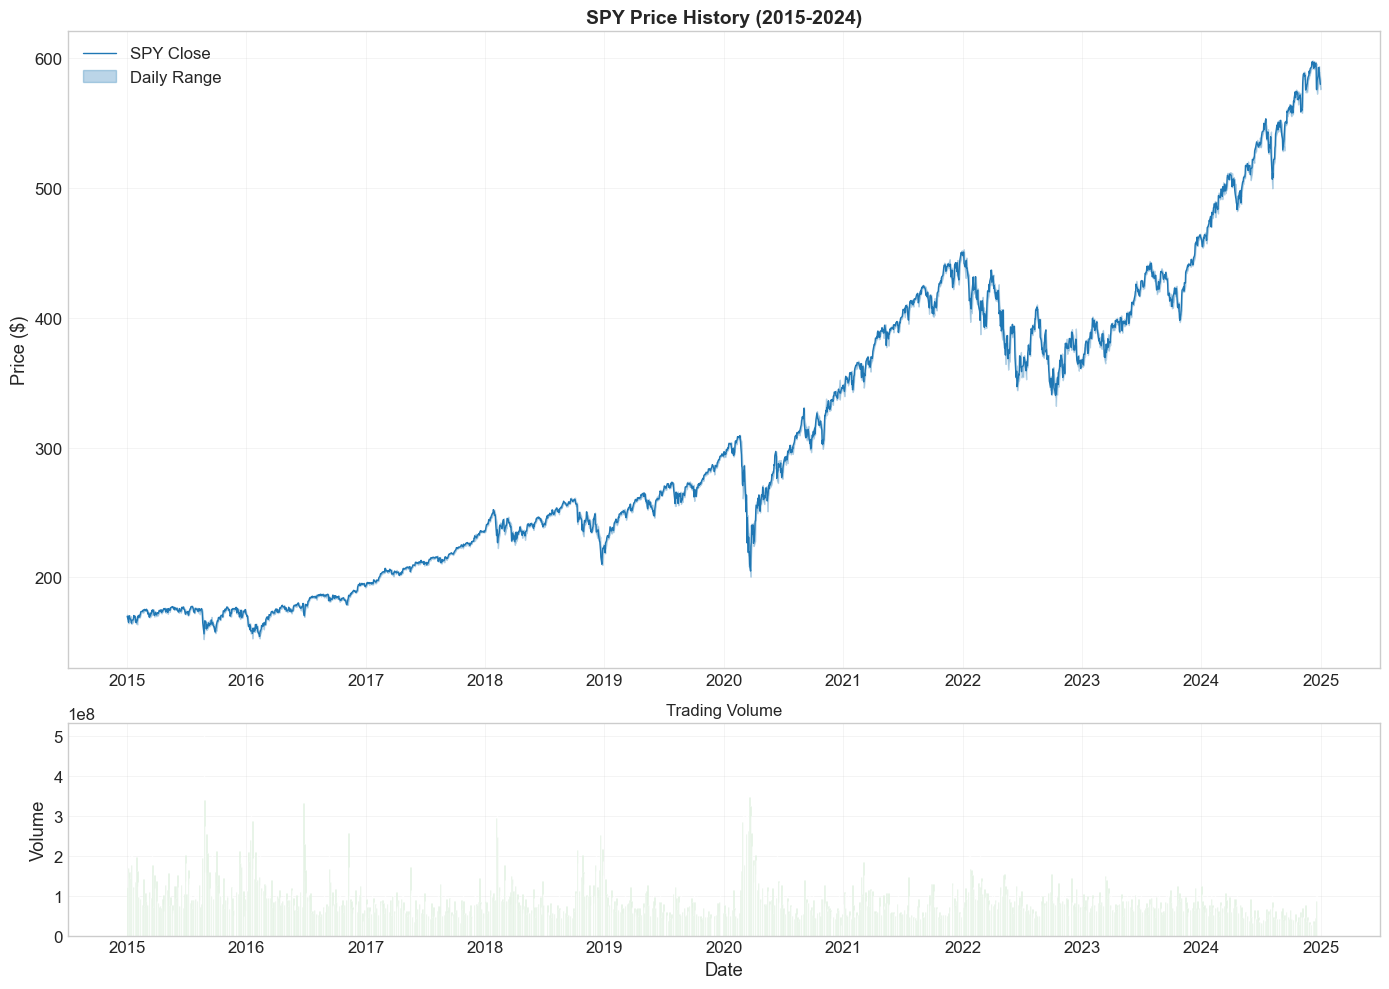

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Set style from config
plt.style.use(CONFIG["visualization"]["style"])
plt.rcParams["figure.figsize"] = CONFIG["visualization"]["figure_size"]
plt.rcParams["font.size"] = 10

# Create price chart
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# Price chart
ax1 = axes[0]
ax1.plot(df.index, df["Close"], linewidth=1, color="#1f77b4", label=f"{TICKER} Close")
ax1.fill_between(df.index, df["Low"], df["High"], alpha=0.3, color="#1f77b4", label="Daily Range")
min_year = df.index.min().year
max_year = df.index.max().year
ax1.set_title(f"{TICKER} Price History ({min_year}-{max_year})", fontsize=14, fontweight="bold")
ax1.set_ylabel("Price ($)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Volume chart
ax2 = axes[1]
ax2.bar(df.index, df["Volume"], width=1, color="#2ca02c", alpha=0.7)
ax2.set_title("Trading Volume", fontsize=12)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

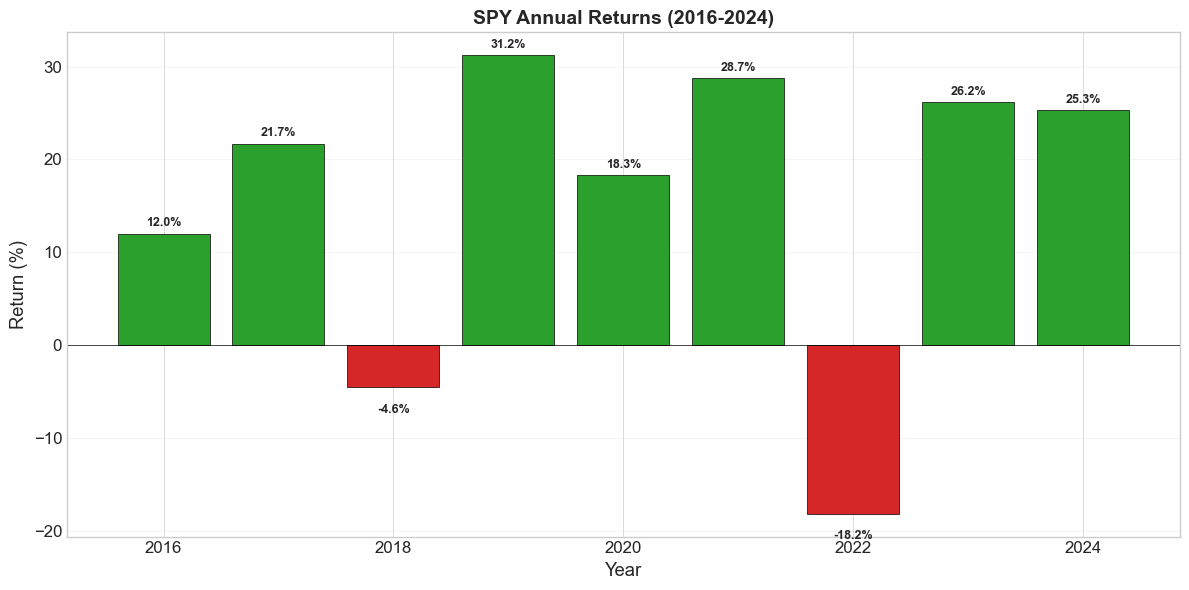

In [8]:
# Annual returns bar chart
fig, ax = plt.subplots(figsize=(12, 6))

years = [y.year for y in annual_returns.index]
returns = [r * 100 for r in annual_returns.values]
colors = ["#2ca02c" if r >= 0 else "#d62728" for r in returns]

bars = ax.bar(years, returns, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title(f"{TICKER} Annual Returns ({years[0]}-{years[-1]})", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Return (%)")
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bar, ret in zip(bars, returns):
    height = bar.get_height()
    ax.annotate(
        f"{ret:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3 if height >= 0 else -12),
        textcoords="offset points",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 4. Strategy Configuration

The Multi-Pattern Strategy uses confluence scoring from 20 pattern detectors.

**Key Parameters:**
- `min_confidence`: Minimum confidence threshold for signals (default: 0.60)
- `min_confluence_count`: Minimum patterns that must agree (default: 2)
- `risk_per_trade`: Risk per trade as fraction of equity (default: 2%)
- `max_open_positions`: Maximum concurrent positions (default: 5)
- `use_regime_filter`: Filter by market regime (default: True)

In [9]:
# Extract config values
INITIAL_CAPITAL = CONFIG["backtest"]["initial_capital"]
COMMISSION = CONFIG["backtest"]["commission"]
strategy_params = CONFIG["strategy"].copy()

print("Backtest Configuration:")
print("=" * 40)
print(f"Initial Capital: ${INITIAL_CAPITAL:,.0f}")
print(f"Commission: {COMMISSION * 100:.1f}%")
print("\nStrategy Parameters:")
for key, value in strategy_params.items():
    print(f"  {key}: {value}")

Backtest Configuration:
Initial Capital: $100,000
Commission: 0.1%

Strategy Parameters:
  min_confidence: 0.5
  min_confluence_count: 1
  risk_per_trade: 0.02
  max_open_positions: 10
  use_regime_filter: True


## 5. Run Backtest

In [10]:
# Prepare data for backtest (remove the Daily_Return column we added)
df_backtest = df[CONFIG["data"]["columns"]].copy()

print("Running Multi-Pattern Strategy Backtest...")
print(f"This may take a few minutes for {len(df)} bars of {TICKER} daily data.\n")

# Initialize runner
runner = BacktestPyRunner(
    data=df_backtest,
    cash=INITIAL_CAPITAL,
    commission=COMMISSION,
    exclusive_orders=CONFIG["backtest"]["exclusive_orders"],
)

# Run backtest
results = runner.run(**strategy_params)

print("\nBacktest completed!")

Running Multi-Pattern Strategy Backtest...
This may take a few minutes for 2515 bars of SPY daily data.

Running backtest on 2515 bars...



Backtest.run:   0%|          | 0/2514 [00:00<?, ?bar/s]

INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #1: SHORT @ 174.10 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #2: LONG @ 171.51 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #3: LONG @ 174.29 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #4: SHORT @ 171.72 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #5: LONG @ 175.65 | Patterns: 2 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #6: SHORT @ 175.33 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #7: SHORT @ 175.78 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #8: LONG @ 176.52 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #9: SHORT @ 177.60 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #10: LONG @ 175.99 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #11: SHORT @ 176.28 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #12: LONG @ 177.00 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #13: SHORT @ 176.21 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #14: LONG @ 172.07 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #15: SHORT @ 173.45 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #16: LONG @ 171.27 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #17: SHORT @ 173.43 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #18: LONG @ 175.52 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #19: SHORT @ 174.13 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #20: LONG @ 162.55 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #21: SHORT @ 166.57 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #22: LONG @ 161.01 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #23: SHORT @ 161.43 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #24: LONG @ 170.02 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #25: SHORT @ 170.66 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #26: LONG @ 172.47 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #27: SHORT @ 170.18 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #28: SHORT @ 169.63 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #29: LONG @ 170.48 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #30: SHORT @ 172.32 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #31: LONG @ 163.69 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #32: SHORT @ 159.60 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #33: LONG @ 162.22 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #34: SHORT @ 158.74 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #35: LONG @ 164.63 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #36: SHORT @ 168.66 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #37: LONG @ 171.87 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #38: SHORT @ 173.89 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #39: LONG @ 175.80 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #40: SHORT @ 175.23 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #41: LONG @ 176.71 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #42: SHORT @ 176.72 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #43: LONG @ 177.77 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #44: SHORT @ 178.50 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #45: LONG @ 173.53 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #46: SHORT @ 176.49 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #47: LONG @ 181.60 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #48: SHORT @ 184.82 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #49: LONG @ 186.33 | Patterns: 4 | Confidence: 0.76


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #50: SHORT @ 186.14 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #51: LONG @ 186.49 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #52: SHORT @ 186.05 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #53: LONG @ 185.92 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #54: SHORT @ 186.48 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #55: LONG @ 184.76 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #56: SHORT @ 182.10 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #57: LONG @ 183.85 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #58: SHORT @ 183.14 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #59: LONG @ 184.44 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #60: SHORT @ 182.43 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #61: LONG @ 182.95 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #62: SHORT @ 194.20 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #63: LONG @ 195.49 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #64: SHORT @ 193.88 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #65: LONG @ 193.74 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #66: SHORT @ 202.65 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #67: LONG @ 204.18 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #68: SHORT @ 202.68 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #69: LONG @ 203.15 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #70: LONG @ 203.40 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #71: SHORT @ 206.90 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #72: SHORT @ 207.04 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #73: LONG @ 208.37 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #74: SHORT @ 208.18 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #75: LONG @ 208.16 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #76: SHORT @ 208.64 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #77: LONG @ 209.64 | Patterns: 1 | Confidence: 0.50


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #78: SHORT @ 209.60 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #79: LONG @ 211.03 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #80: SHORT @ 211.57 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #81: LONG @ 213.19 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #82: SHORT @ 211.75 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #83: LONG @ 210.97 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #84: SHORT @ 211.19 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #85: LONG @ 212.62 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #86: SHORT @ 213.95 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #87: LONG @ 215.99 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #88: SHORT @ 215.45 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #89: LONG @ 214.83 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #90: SHORT @ 214.80 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #91: LONG @ 211.65 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #92: SHORT @ 213.87 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #93: LONG @ 217.15 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #94: SHORT @ 217.99 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #95: LONG @ 220.00 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #96: SHORT @ 222.75 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #97: LONG @ 223.26 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #98: SHORT @ 227.88 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #99: LONG @ 230.19 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #100: SHORT @ 231.30 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #101: LONG @ 234.57 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #102: SHORT @ 234.88 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #103: LONG @ 236.56 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #104: SHORT @ 241.27 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #105: LONG @ 243.03 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #106: SHORT @ 243.78 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #107: LONG @ 248.81 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #108: SHORT @ 232.30 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #109: LONG @ 236.88 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #110: SHORT @ 226.76 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #111: LONG @ 230.16 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #112: SHORT @ 233.00 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #113: LONG @ 234.28 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #114: SHORT @ 227.52 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #115: LONG @ 234.74 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #116: SHORT @ 232.97 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #117: LONG @ 240.38 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #118: SHORT @ 241.23 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #119: LONG @ 241.57 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #120: SHORT @ 240.56 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #121: LONG @ 240.46 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #122: SHORT @ 253.39 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #123: LONG @ 257.23 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #124: SHORT @ 257.69 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #125: LONG @ 260.60 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #126: SHORT @ 248.15 | Patterns: 2 | Confidence: 0.78


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #127: LONG @ 250.03 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #128: SHORT @ 243.97 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #129: LONG @ 240.82 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #130: LONG @ 250.57 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #131: SHORT @ 242.59 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #132: LONG @ 227.45 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #133: SHORT @ 224.04 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #134: LONG @ 220.79 | Patterns: 4 | Confidence: 0.69


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #135: SHORT @ 222.49 | Patterns: 3 | Confidence: 0.73


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #136: LONG @ 226.36 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #137: SHORT @ 254.40 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #138: LONG @ 256.49 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #139: SHORT @ 251.56 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #140: LONG @ 254.47 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #141: SHORT @ 253.01 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #142: LONG @ 255.30 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #143: LONG @ 255.79 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #144: SHORT @ 254.16 | Patterns: 4 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #145: LONG @ 254.74 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #146: SHORT @ 252.37 | Patterns: 3 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #147: SHORT @ 259.13 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #148: SHORT @ 260.31 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #149: SHORT @ 260.25 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #150: SHORT @ 260.67 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #151: LONG @ 263.40 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #152: SHORT @ 263.20 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #153: LONG @ 270.48 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #154: SHORT @ 270.17 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #155: LONG @ 272.15 | Patterns: 1 | Confidence: 0.50


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #156: SHORT @ 271.37 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #157: LONG @ 272.87 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #158: SHORT @ 271.56 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #159: LONG @ 273.38 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #160: SHORT @ 272.89 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #161: LONG @ 260.68 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #162: SHORT @ 265.79 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #163: LONG @ 264.85 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #164: SHORT @ 263.18 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #165: LONG @ 269.59 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #166: SHORT @ 269.80 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #167: LONG @ 271.79 | Patterns: 1 | Confidence: 0.50


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #168: SHORT @ 269.06 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #169: SHORT @ 268.64 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #170: SHORT @ 269.88 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #171: SHORT @ 266.67 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #172: LONG @ 267.68 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #173: SHORT @ 266.53 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #174: LONG @ 264.88 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #175: SHORT @ 270.97 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #176: LONG @ 278.40 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #177: SHORT @ 295.64 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #178: LONG @ 305.85 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #179: SHORT @ 285.72 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #180: LONG @ 282.47 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #181: LONG @ 271.84 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #182: SHORT @ 250.61 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #183: LONG @ 263.58 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #184: SHORT @ 250.73 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #185: LONG @ 246.12 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #186: SHORT @ 219.19 | Patterns: 4 | Confidence: 0.59


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #187: LONG @ 231.03 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #188: LONG @ 263.87 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #189: SHORT @ 278.50 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #190: LONG @ 293.55 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #191: SHORT @ 294.88 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #192: LONG @ 299.44 | Patterns: 1 | Confidence: 0.50


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #193: SHORT @ 322.51 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #194: LONG @ 325.55 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #195: SHORT @ 318.89 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #196: LONG @ 321.52 | Patterns: 1 | Confidence: 0.50


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #197: SHORT @ 324.56 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #198: LONG @ 305.89 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #199: SHORT @ 302.70 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #200: LONG @ 306.09 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #201: SHORT @ 311.49 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #202: LONG @ 328.67 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #203: SHORT @ 328.19 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #204: LONG @ 331.95 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #205: SHORT @ 334.29 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #206: LONG @ 339.29 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #207: SHORT @ 340.01 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #208: LONG @ 342.84 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #209: SHORT @ 342.14 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #210: LONG @ 343.14 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #211: SHORT @ 340.06 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #212: LONG @ 345.06 | Patterns: 4 | Confidence: 0.62


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #213: SHORT @ 343.68 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #214: SHORT @ 342.45 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #215: LONG @ 341.88 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #216: SHORT @ 342.18 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #217: LONG @ 346.47 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #218: SHORT @ 343.32 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #219: LONG @ 352.92 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #220: SHORT @ 352.54 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #221: LONG @ 357.38 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #222: SHORT @ 360.30 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #223: LONG @ 357.13 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #224: SHORT @ 379.75 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #225: SHORT @ 384.46 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #226: LONG @ 388.42 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #227: SHORT @ 388.18 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #228: LONG @ 394.25 | Patterns: 2 | Confidence: 0.62


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #229: SHORT @ 390.35 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #230: LONG @ 383.19 | Patterns: 2 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #231: SHORT @ 405.67 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #232: LONG @ 408.10 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #233: LONG @ 412.24 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #234: SHORT @ 423.13 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #235: SHORT @ 417.39 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #236: LONG @ 411.61 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #237: SHORT @ 403.41 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #238: LONG @ 408.20 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #239: SHORT @ 402.94 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #240: LONG @ 407.13 | Patterns: 3 | Confidence: 0.63


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #241: SHORT @ 428.24 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #242: LONG @ 429.97 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #243: LONG @ 450.22 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #244: SHORT @ 449.85 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #245: SHORT @ 421.44 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #246: LONG @ 408.83 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #247: LONG @ 424.42 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #248: SHORT @ 415.50 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #249: LONG @ 404.03 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #250: SHORT @ 395.67 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #251: LONG @ 410.94 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #252: SHORT @ 422.53 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #253: LONG @ 405.49 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #254: SHORT @ 393.74 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #255: LONG @ 404.83 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #256: SHORT @ 389.86 | Patterns: 2 | Confidence: 0.78


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #257: LONG @ 392.21 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #258: SHORT @ 391.58 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #259: LONG @ 377.65 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #260: SHORT @ 371.65 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #261: LONG @ 383.53 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #262: SHORT @ 379.87 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #263: LONG @ 358.83 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #264: SHORT @ 346.95 | Patterns: 2 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #265: LONG @ 347.70 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #266: SHORT @ 375.48 | Patterns: 3 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #267: LONG @ 381.13 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #268: SHORT @ 390.38 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #269: LONG @ 393.88 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #270: SHORT @ 385.19 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #271: LONG @ 376.74 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #272: SHORT @ 360.13 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #273: LONG @ 346.76 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #274: SHORT @ 340.84 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #275: LONG @ 367.32 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #276: SHORT @ 364.55 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #277: LONG @ 371.23 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #278: SHORT @ 377.92 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #279: LONG @ 381.61 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #280: SHORT @ 383.93 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #281: LONG @ 389.03 | Patterns: 1 | Confidence: 0.80


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #282: SHORT @ 388.75 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #283: LONG @ 364.80 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #284: SHORT @ 370.26 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #285: LONG @ 384.06 | Patterns: 1 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #286: SHORT @ 395.30 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #287: LONG @ 369.42 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #288: SHORT @ 375.53 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #289: LONG @ 379.73 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #290: SHORT @ 375.29 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #291: LONG @ 386.22 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #292: SHORT @ 393.27 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #293: LONG @ 397.88 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #294: SHORT @ 396.91 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #295: LONG @ 400.25 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #296: SHORT @ 399.85 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #297: LONG @ 397.29 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #298: SHORT @ 396.60 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #299: LONG @ 399.58 | Patterns: 3 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #300: SHORT @ 402.84 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #301: LONG @ 404.19 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #302: SHORT @ 404.34 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #303: LONG @ 405.92 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #304: SHORT @ 411.00 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #305: SHORT @ 420.70 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #306: LONG @ 425.92 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #307: SHORT @ 424.47 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #308: LONG @ 430.80 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #309: SHORT @ 434.77 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #310: LONG @ 421.61 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #311: SHORT @ 425.17 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #312: LONG @ 416.35 | Patterns: 3 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #313: SHORT @ 420.34 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #314: LONG @ 402.83 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #315: SHORT @ 405.36 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #316: LONG @ 427.08 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #317: SHORT @ 455.72 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #318: LONG @ 469.51 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #319: SHORT @ 498.58 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #320: SHORT @ 498.01 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #321: LONG @ 508.11 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #322: SHORT @ 508.83 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #323: SHORT @ 492.46 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #324: LONG @ 487.85 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #325: SHORT @ 529.88 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #326: LONG @ 534.10 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #327: SHORT @ 535.46 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #328: LONG @ 540.09 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #329: SHORT @ 545.01 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #330: LONG @ 553.22 | Patterns: 1 | Confidence: 0.50


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #331: SHORT @ 530.08 | Patterns: 2 | Confidence: 0.78


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #332: LONG @ 527.31 | Patterns: 1 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #333: SHORT @ 521.92 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #334: LONG @ 511.39 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #335: SHORT @ 519.71 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #336: LONG @ 544.76 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #337: SHORT @ 538.28 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #338: LONG @ 559.21 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #339: SHORT @ 569.57 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #340: SHORT @ 569.80 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #341: LONG @ 560.99 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #342: SHORT @ 559.78 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #343: LONG @ 580.63 | Patterns: 1 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #344: SHORT @ 588.22 | Patterns: 1 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #345: LONG @ 583.22 | Patterns: 1 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #346: SHORT @ 575.96 | Patterns: 3 | Confidence: 0.72


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #347: LONG @ 582.70 | Patterns: 4 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #348: SHORT @ 579.81 | Patterns: 1 | Confidence: 0.75



BACKTEST SUMMARY
Start Date: 2015-01-02 00:00:00
End Date: 2024-12-30 00:00:00
Duration: 3650 days 00:00:00

Initial Capital: $100,000.00
Final Equity: $84,317.67
Final Return: -15.68%

Total Trades: 346
Win Rate: 29.19%
Best Trade: 11.94%
Worst Trade: -7.09%
Avg Trade: -0.32%

Max Drawdown: -16.99%
Sharpe Ratio: -0.59
Sortino Ratio: -0.81
Calmar Ratio: -0.10


Backtest completed!


## 6. Performance Results

In [11]:
# Display key metrics
stats = results["stats"]

print("=" * 60)
print("BACKTEST PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\n{'Return Metrics':^40}")
print("-" * 40)
print(
    f"Total Return:          {stats.get('Return [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Return [%]"), (int, float))
    else f"Total Return:          {stats.get('Return [%]', 'N/A')}"
)
print(
    f"Buy & Hold Return:     {stats.get('Buy & Hold Return [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Buy & Hold Return [%]"), (int, float))
    else f"Buy & Hold Return:     {stats.get('Buy & Hold Return [%]', 'N/A')}"
)
print(
    f"Annual Return:         {stats.get('Return (Ann.) [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Return (Ann.) [%]"), (int, float))
    else f"Annual Return:         {stats.get('Return (Ann.) [%]', 'N/A')}"
)

print(f"\n{'Risk Metrics':^40}")
print("-" * 40)
print(
    f"Sharpe Ratio:          {stats.get('Sharpe Ratio', 'N/A'):.2f}"
    if isinstance(stats.get("Sharpe Ratio"), (int, float))
    else f"Sharpe Ratio:          {stats.get('Sharpe Ratio', 'N/A')}"
)
print(
    f"Sortino Ratio:         {stats.get('Sortino Ratio', 'N/A'):.2f}"
    if isinstance(stats.get("Sortino Ratio"), (int, float))
    else f"Sortino Ratio:         {stats.get('Sortino Ratio', 'N/A')}"
)
print(
    f"Max Drawdown:          {stats.get('Max. Drawdown [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Max. Drawdown [%]"), (int, float))
    else f"Max Drawdown:          {stats.get('Max. Drawdown [%]', 'N/A')}"
)
print(
    f"Volatility (Ann.):     {stats.get('Volatility (Ann.) [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Volatility (Ann.) [%]"), (int, float))
    else f"Volatility (Ann.):     {stats.get('Volatility (Ann.) [%]', 'N/A')}"
)

print(f"\n{'Trade Statistics':^40}")
print("-" * 40)
print(f"Total Trades:          {stats.get('# Trades', 'N/A')}")
print(
    f"Win Rate:              {stats.get('Win Rate [%]', 'N/A'):.1f}%"
    if isinstance(stats.get("Win Rate [%]"), (int, float))
    else f"Win Rate:              {stats.get('Win Rate [%]', 'N/A')}"
)
print(
    f"Best Trade:            {stats.get('Best Trade [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Best Trade [%]"), (int, float))
    else f"Best Trade:            {stats.get('Best Trade [%]', 'N/A')}"
)
print(
    f"Worst Trade:           {stats.get('Worst Trade [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Worst Trade [%]"), (int, float))
    else f"Worst Trade:           {stats.get('Worst Trade [%]', 'N/A')}"
)
print(
    f"Avg. Trade:            {stats.get('Avg. Trade [%]', 'N/A'):.2f}%"
    if isinstance(stats.get("Avg. Trade [%]"), (int, float))
    else f"Avg. Trade:            {stats.get('Avg. Trade [%]', 'N/A')}"
)
print(f"Max. Trade Duration:   {stats.get('Max. Trade Duration', 'N/A')}")
print(f"Avg. Trade Duration:   {stats.get('Avg. Trade Duration', 'N/A')}")

print(f"\n{'Other Metrics':^40}")
print("-" * 40)
print(
    f"Final Equity:          ${stats.get('Equity Final [$]', 'N/A'):,.0f}"
    if isinstance(stats.get("Equity Final [$]"), (int, float))
    else f"Final Equity:          {stats.get('Equity Final [$]', 'N/A')}"
)
print(
    f"Peak Equity:           ${stats.get('Equity Peak [$]', 'N/A'):,.0f}"
    if isinstance(stats.get("Equity Peak [$]"), (int, float))
    else f"Peak Equity:           {stats.get('Equity Peak [$]', 'N/A')}"
)

BACKTEST PERFORMANCE SUMMARY

             Return Metrics             
----------------------------------------
Total Return:          -15.68%
Buy & Hold Return:     240.81%
Annual Return:         -1.69%

              Risk Metrics              
----------------------------------------
Sharpe Ratio:          -0.59
Sortino Ratio:         -0.81
Max Drawdown:          -16.99%
Volatility (Ann.):     2.89%

            Trade Statistics            
----------------------------------------
Total Trades:          346
Win Rate:              29.2%
Best Trade:            11.94%
Worst Trade:           -7.09%
Avg. Trade:            -0.32%
Max. Trade Duration:   85 days 00:00:00
Avg. Trade Duration:   9 days 00:00:00

             Other Metrics              
----------------------------------------
Final Equity:          $84,318
Peak Equity:           $100,969


In [12]:
# Display all stats
print("\n" + "=" * 60)
print("DETAILED STATISTICS")
print("=" * 60)
for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


DETAILED STATISTICS
Start: 2015-01-02 00:00:00
End: 2024-12-30 00:00:00
Duration: 3650 days 00:00:00
Exposure Time [%]: 88.2306
Equity Final [$]: 84317.6715
Equity Peak [$]: 100969.3789
Commissions [$]: 12037.0683
Return [%]: -15.6823
Buy & Hold Return [%]: 240.8136
Return (Ann.) [%]: -1.6947
Volatility (Ann.) [%]: 2.8857
CAGR [%]: -1.1708
Sharpe Ratio: -0.5873
Sortino Ratio: -0.8100
Calmar Ratio: -0.0997
Alpha [%]: -7.2286
Beta: -0.0351
Max. Drawdown [%]: -16.9914
Avg. Drawdown [%]: -3.9665
Max. Drawdown Duration: 3381 days 00:00:00
Avg. Drawdown Duration: 718 days 00:00:00
# Trades: 346
Win Rate [%]: 29.1908
Best Trade [%]: 11.9422
Worst Trade [%]: -7.0889
Avg. Trade [%]: -0.3168
Max. Trade Duration: 85 days 00:00:00
Avg. Trade Duration: 9 days 00:00:00
Profit Factor: 0.6939
Expectancy [%]: -0.2902
SQN: -2.1349
Kelly Criterion: -0.1174
_strategy: MultiPatternStrategy(min_confidence=0.5,min_confluence_count=1,risk_per_trade=0.02,max_open_positions=10,use_regime_filter=True)
_equity_c

## 7. Visualizations

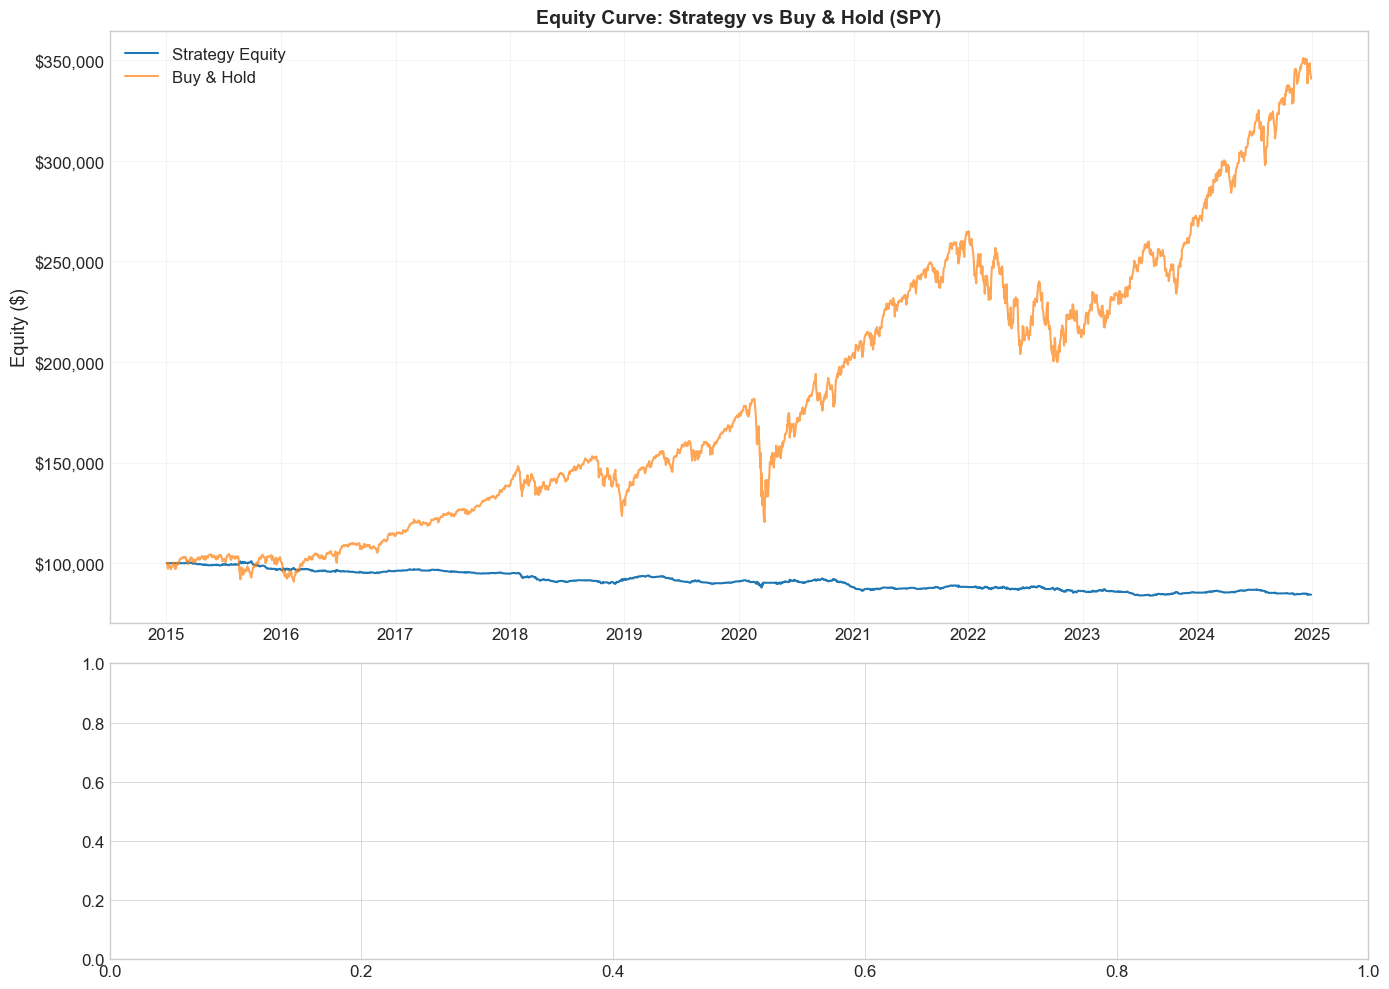

In [13]:
# Plot equity curve
if "equity_curve" in results:
    equity_df = results["equity_curve"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2, 1]})

    # Equity curve
    ax1 = axes[0]
    ax1.plot(
        equity_df.index,
        equity_df["Equity"],
        linewidth=1.5,
        color="#1f77b4",
        label="Strategy Equity",
    )

    # Buy & Hold comparison
    initial_price = df_backtest["Close"].iloc[0]
    final_price = df_backtest["Close"]
    buy_hold_equity = INITIAL_CAPITAL * (final_price / initial_price)
    ax1.plot(
        buy_hold_equity.index,
        buy_hold_equity,
        linewidth=1.5,
        color="#ff7f0e",
        label="Buy & Hold",
        alpha=0.7,
    )

    ax1.set_title(
        f"Equity Curve: Strategy vs Buy & Hold ({TICKER})", fontsize=14, fontweight="bold"
    )
    ax1.set_ylabel("Equity ($)")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))

    # Drawdown
    ax2 = axes[1]
    if "Drawdown" in equity_df.columns:
        ax2.fill_between(
            equity_df.index,
            equity_df["Drawdown"] * 100,
            0,
            color="#d62728",
            alpha=0.5,
            label="Drawdown",
        )
        ax2.set_title("Strategy Drawdown", fontsize=12)
        ax2.set_ylabel("Drawdown (%)")
        ax2.set_xlabel("Date")
        ax2.legend(loc="lower left")
        ax2.grid(True, alpha=0.3)
        ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("Equity curve data not available. Plotting from backtest results...")
    # Alternative: use backtesting.py's built-in plot
    try:
        output_path = get_output_path(CONFIG, project_root, CONFIG["output"]["plot_filename"])
        runner.bt.plot(filename=str(output_path), open_browser=False)
        print(f"Plot saved to '{output_path}'")
    except Exception as e:
        print(f"Could not generate plot: {e}")

TRADE ANALYSIS


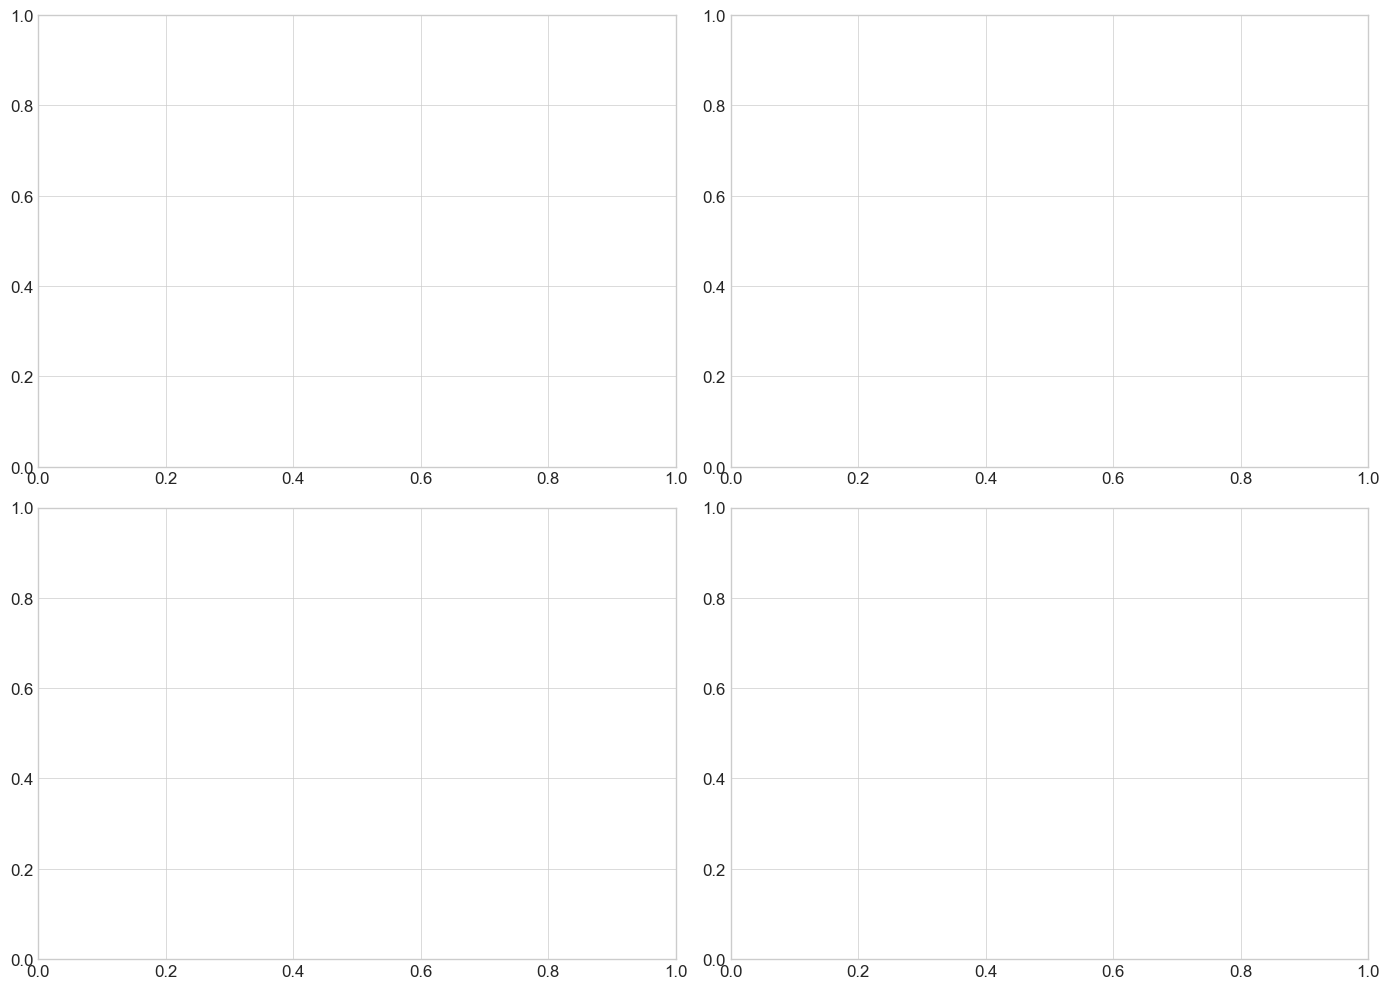


First 20 Trades:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [14]:
# Trade analysis
if "trades" in results and results["trades"] is not None:
    trades_df = results["trades"]

    if len(trades_df) > 0:
        print("=" * 60)
        print("TRADE ANALYSIS")
        print("=" * 60)

        # Trade distribution
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Trade PnL distribution
        ax1 = axes[0, 0]
        if "PnL" in trades_df.columns:
            pnl = trades_df["PnL"]
            wins = pnl[pnl > 0]
            losses = pnl[pnl < 0]
            ax1.hist(wins, bins=20, color="#2ca02c", alpha=0.7, label=f"Wins ({len(wins)})")
            ax1.hist(losses, bins=20, color="#d62728", alpha=0.7, label=f"Losses ({len(losses)})")
            ax1.axvline(x=0, color="black", linewidth=1)
            ax1.set_title("Trade PnL Distribution", fontsize=12)
            ax1.set_xlabel("PnL ($)")
            ax1.set_ylabel("Frequency")
            ax1.legend()
            ax1.grid(True, alpha=0.3)

        # Trade returns distribution
        ax2 = axes[0, 1]
        if "ReturnPct" in trades_df.columns:
            returns = trades_df["ReturnPct"] * 100
            ax2.hist(returns, bins=30, color="#1f77b4", alpha=0.7, edgecolor="black")
            ax2.axvline(x=0, color="red", linewidth=1, linestyle="--")
            ax2.set_title("Trade Return % Distribution", fontsize=12)
            ax2.set_xlabel("Return (%)")
            ax2.set_ylabel("Frequency")
            ax2.grid(True, alpha=0.3)

        # Trades over time
        ax3 = axes[1, 0]
        if "EntryTime" in trades_df.columns:
            trades_df_sorted = trades_df.sort_values("EntryTime")
            cumulative_pnl = trades_df_sorted["PnL"].cumsum()
            ax3.plot(trades_df_sorted["EntryTime"], cumulative_pnl, linewidth=1.5, color="#1f77b4")
            ax3.fill_between(
                trades_df_sorted["EntryTime"],
                0,
                cumulative_pnl,
                where=(cumulative_pnl >= 0),
                color="#2ca02c",
                alpha=0.3,
            )
            ax3.fill_between(
                trades_df_sorted["EntryTime"],
                0,
                cumulative_pnl,
                where=(cumulative_pnl < 0),
                color="#d62728",
                alpha=0.3,
            )
            ax3.set_title("Cumulative Trade PnL", fontsize=12)
            ax3.set_xlabel("Date")
            ax3.set_ylabel("Cumulative PnL ($)")
            ax3.grid(True, alpha=0.3)
            ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))

        # Trade duration vs PnL
        ax4 = axes[1, 1]
        if "Duration" in trades_df.columns and "PnL" in trades_df.columns:
            durations = (
                trades_df["Duration"].dt.days
                if hasattr(trades_df["Duration"].dt, "days")
                else trades_df["Duration"]
            )
            colors = ["#2ca02c" if pnl > 0 else "#d62728" for pnl in trades_df["PnL"]]
            ax4.scatter(
                durations, trades_df["PnL"], c=colors, alpha=0.6, edgecolors="black", linewidth=0.5
            )
            ax4.axhline(y=0, color="black", linewidth=0.5)
            ax4.set_title("Trade Duration vs PnL", fontsize=12)
            ax4.set_xlabel("Duration (days)")
            ax4.set_ylabel("PnL ($)")
            ax4.grid(True, alpha=0.3)
            ax4.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))

        plt.tight_layout()
        plt.show()

        # Trade table (first 20 trades)
        print("\nFirst 20 Trades:")
        display_cols = ["EntryTime", "ExitTime", "EntryPrice", "ExitPrice", "PnL", "ReturnPct"]
        display_cols = [c for c in display_cols if c in trades_df.columns]
        print(trades_df[display_cols].head(20).to_string())
    else:
        print("No trades were executed during the backtest period.")
else:
    print("Trade data not available in results.")

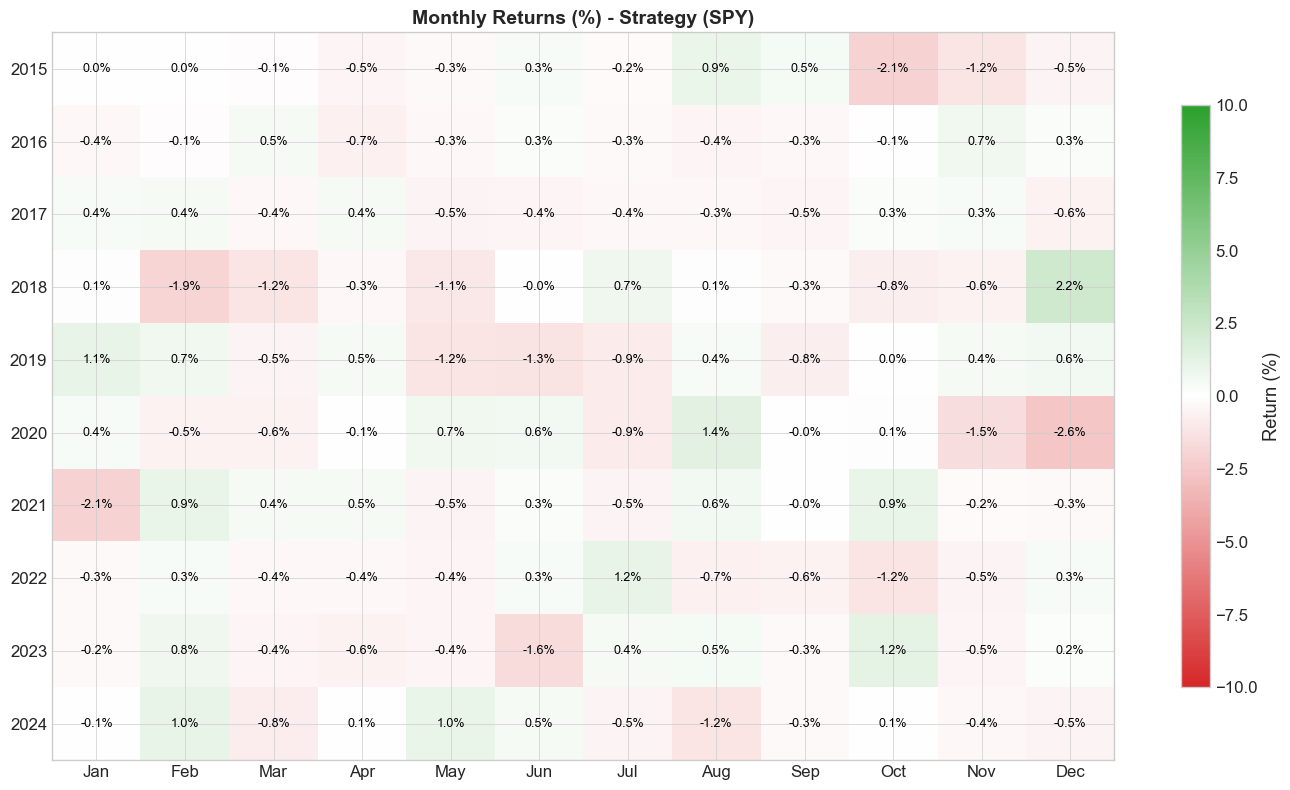

In [15]:
# Monthly returns heatmap
if "equity_curve" in results:
    equity_df = results["equity_curve"]

    # Calculate daily returns from equity
    equity_df["DailyReturn"] = equity_df["Equity"].pct_change()

    # Calculate monthly returns
    monthly_returns = equity_df["DailyReturn"].resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_returns_pct = monthly_returns * 100

    # Create month-year pivot table
    monthly_df = pd.DataFrame(
        {
            "Year": monthly_returns_pct.index.year,
            "Month": monthly_returns_pct.index.month,
            "Return": monthly_returns_pct.values,
        }
    )

    pivot_table = monthly_df.pivot(index="Year", columns="Month", values="Return")
    pivot_table.columns = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(14, 8))

    import matplotlib.colors as mcolors

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom", ["#d62728", "#ffffff", "#2ca02c"], N=256
    )

    im = ax.imshow(pivot_table.values, cmap=cmap, aspect="auto", vmin=-10, vmax=10)

    # Labels
    ax.set_xticks(range(12))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)

    # Add text annotations
    for i in range(len(pivot_table.index)):
        for j in range(12):
            val = pivot_table.iloc[i, j]
            if not np.isnan(val):
                color = "white" if abs(val) > 5 else "black"
                text = ax.text(
                    j, i, f"{val:.1f}%", ha="center", va="center", color=color, fontsize=9
                )

    ax.set_title(f"Monthly Returns (%) - Strategy ({TICKER})", fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax, label="Return (%)", shrink=0.8)
    plt.tight_layout()
    plt.show()

## 8. Summary and Analysis

In [16]:
# Calculate buy & hold metrics for comparison
initial_price = df_backtest["Close"].iloc[0]
final_price = df_backtest["Close"].iloc[-1]
buy_hold_return = (final_price / initial_price - 1) * 100
years = (df_backtest.index[-1] - df_backtest.index[0]).days / 365.25
buy_hold_annual = ((final_price / initial_price) ** (1 / years) - 1) * 100

# Strategy metrics
strategy_return = stats.get("Return [%]", 0)
strategy_annual = stats.get("Return (Ann.) [%]", 0)
sharpe = stats.get("Sharpe Ratio", 0)
max_dd = stats.get("Max. Drawdown [%]", 0)
win_rate = stats.get("Win Rate [%]", 0)
total_trades = stats.get("# Trades", 0)

print("=" * 70)
print("STRATEGY vs BUY & HOLD COMPARISON")
print("=" * 70)
print(f"\n{'Metric':<30} {'Strategy':<20} {'Buy & Hold':<20}")
print("-" * 70)
print(f"{'Total Return':<30} {strategy_return:>18.2f}% {buy_hold_return:>18.2f}%")
print(f"{'Annualized Return':<30} {strategy_annual:>18.2f}% {buy_hold_annual:>18.2f}%")
print(f"{'Sharpe Ratio':<30} {sharpe:>18.2f} {'N/A':>18}")
print(f"{'Max Drawdown':<30} {max_dd:>18.2f}% {'N/A':>18}")
print(f"{'Total Trades':<30} {total_trades:>18} {'N/A':>18}")
print(f"{'Win Rate':<30} {win_rate:>17.1f}% {'N/A':>18}")

print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)

if strategy_return > buy_hold_return:
    print(f"✓ Strategy OUTPERFORMED Buy & Hold by {strategy_return - buy_hold_return:.2f}%")
else:
    print(f"✗ Strategy UNDERPERFORMED Buy & Hold by {buy_hold_return - strategy_return:.2f}%")

if sharpe > 1:
    print("✓ Good risk-adjusted returns (Sharpe > 1)")
elif sharpe > 0.5:
    print("○ Moderate risk-adjusted returns (Sharpe > 0.5)")
else:
    print("✗ Low risk-adjusted returns (Sharpe < 0.5)")

if max_dd > -20:
    print("✓ Controlled drawdown (< 20%)")
elif max_dd > -35:
    print("○ Moderate drawdown (20-35%)")
else:
    print("✗ Significant drawdown (> 35%)")

if win_rate > 50:
    print(f"✓ Positive win rate ({win_rate:.1f}%)")
else:
    print(f"✗ Win rate below 50% ({win_rate:.1f}%)")

STRATEGY vs BUY & HOLD COMPARISON

Metric                         Strategy             Buy & Hold          
----------------------------------------------------------------------
Total Return                               -15.68%             240.81%
Annualized Return                           -1.69%              13.05%
Sharpe Ratio                                -0.59                N/A
Max Drawdown                               -16.99%                N/A
Total Trades                                  346                N/A
Win Rate                                    29.2%                N/A

KEY TAKEAWAYS
✗ Strategy UNDERPERFORMED Buy & Hold by 256.50%
✗ Low risk-adjusted returns (Sharpe < 0.5)
✓ Controlled drawdown (< 20%)
✗ Win rate below 50% (29.2%)


## 9. Benchmark Comparison (Alpha/Beta Analysis)

This section answers the critical question: **Is this the market growing or is my strategy being smart?**

Key metrics:
- **Alpha**: Excess return after adjusting for market exposure (positive = skill)
- **Beta**: Sensitivity to market movements (< 1 = defensive, > 1 = aggressive)
- **Information Ratio**: Risk-adjusted excess return vs benchmark
- **Tracking Error**: How closely the strategy follows the benchmark

In [17]:
# Import benchmark comparison module
from src.backtest import BenchmarkComparison, RiskMetrics

# Calculate strategy returns from equity curve
if "equity_curve" in results and results["equity_curve"] is not None:
    equity_df = results["equity_curve"]
    strategy_returns = equity_df["Equity"].pct_change().dropna()
else:
    # Calculate from trades
    strategy_returns = pd.Series(dtype=float)

# Calculate benchmark returns (uses same OHLCV data as the ticker)
benchmark_returns = df_backtest["Close"].pct_change().dropna()

# Align dates
aligned_strategy = strategy_returns
aligned_benchmark = benchmark_returns.reindex(aligned_strategy.index).dropna()
aligned_strategy = aligned_strategy.reindex(aligned_benchmark.index).dropna()

print(f"Strategy observations: {len(aligned_strategy)}")
print(f"Benchmark observations: {len(aligned_benchmark)}")

Strategy observations: 2514
Benchmark observations: 2514


In [18]:
# Calculate benchmark comparison metrics
if len(aligned_strategy) > 30:
    benchmark_metrics = BenchmarkComparison.calculate(
        strategy_returns=aligned_strategy,
        benchmark_returns=aligned_benchmark,
        risk_free_rate=CONFIG["benchmark"]["risk_free_rate"],
        periods_per_year=CONFIG["benchmark"]["periods_per_year"],
    )

    print("=" * 70)
    print("BENCHMARK COMPARISON ANALYSIS")
    print("=" * 70)
    print("\n" + "-" * 70)
    print("RETURN COMPARISON")
    print("-" * 70)
    print(
        f"{'Strategy Total Return:':<35} {benchmark_metrics.get('strategy_total_return', 0) * 100:>15.2f}%"
    )
    print(
        f"{'Benchmark Total Return:':<35} {benchmark_metrics.get('benchmark_total_return', 0) * 100:>15.2f}%"
    )
    print(f"{'Excess Return:':<35} {benchmark_metrics.get('excess_return', 0) * 100:>15.2f}%")
    print(
        f"{'Strategy Annualized Return:':<35} {benchmark_metrics.get('strategy_annualized_return', 0) * 100:>15.2f}%"
    )
    print(
        f"{'Benchmark Annualized Return:':<35} {benchmark_metrics.get('benchmark_annualized_return', 0) * 100:>15.2f}%"
    )

    print("\n" + "-" * 70)
    print("RISK-ADJUSTED METRICS")
    print("-" * 70)
    print(f"{"Alpha (Jensen's):":<35} {benchmark_metrics.get('alpha', 0) * 100:>15.2f}%")
    print(f"{'Beta:':<35} {benchmark_metrics.get('beta', 0):>15.3f}")
    print(f"{'Information Ratio:':<35} {benchmark_metrics.get('information_ratio', 0):>15.3f}")
    print(f"{'Tracking Error:':<35} {benchmark_metrics.get('tracking_error', 0) * 100:>15.2f}%")
    print(f"{'R-Squared:':<35} {benchmark_metrics.get('r_squared', 0):>15.3f}")
    print(f"{'Correlation:':<35} {benchmark_metrics.get('correlation', 0):>15.3f}")

    print("\n" + "-" * 70)
    print("ADDITIONAL RATIOS")
    print("-" * 70)
    print(f"{'Strategy Sharpe:':<35} {benchmark_metrics.get('strategy_sharpe', 0):>15.3f}")
    print(f"{'Benchmark Sharpe:':<35} {benchmark_metrics.get('benchmark_sharpe', 0):>15.3f}")
    print(f"{'Treynor Ratio:':<35} {benchmark_metrics.get('treynor_ratio', 0):>15.3f}")
    print(f"{'M2 (Modigliani):':<35} {benchmark_metrics.get('m2_measure', 0) * 100:>15.2f}%")

    print("\n" + "-" * 70)
    print("MARKET REGIME PERFORMANCE")
    print("-" * 70)
    print(f"{'Up Market Capture:':<35} {benchmark_metrics.get('up_capture', 0):>15.2f}")
    print(f"{'Down Market Capture:':<35} {benchmark_metrics.get('down_capture', 0):>15.2f}")
    print(f"{'Batting Average:':<35} {benchmark_metrics.get('batting_average', 0) * 100:>14.1f}%")

    print("\n" + "-" * 70)
    print("STATISTICAL SIGNIFICANCE")
    print("-" * 70)
    print(f"{'Alpha T-Statistic:':<35} {benchmark_metrics.get('alpha_t_stat', 0):>15.3f}")
    print(f"{'Alpha P-Value:':<35} {benchmark_metrics.get('alpha_p_value', 0):>15.4f}")
    alpha_sig = "Yes" if benchmark_metrics.get("alpha_significant", False) else "No"
    print(f"{'Alpha Significant (5% level):':<35} {alpha_sig:>15}")

    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print(benchmark_metrics.get("interpretation", "N/A"))
else:
    print("Insufficient data for benchmark comparison (need at least 30 observations)")

BENCHMARK COMPARISON ANALYSIS

----------------------------------------------------------------------
RETURN COMPARISON
----------------------------------------------------------------------
Strategy Total Return:                       -15.68%
Benchmark Total Return:                      240.81%
Excess Return:                              -256.50%
Strategy Annualized Return:                   -1.70%
Benchmark Annualized Return:                  13.08%

----------------------------------------------------------------------
RISK-ADJUSTED METRICS
----------------------------------------------------------------------
Alpha (Jensen's):                             -6.36%
Beta:                                        -0.035
Information Ratio:                           -0.800
Tracking Error:                               18.46%
R-Squared:                                    0.044
Correlation:                                 -0.210

----------------------------------------------------------------

## 10. Advanced Risk Metrics

Comprehensive risk analysis including:
- **Value at Risk (VaR)**: Maximum expected loss at given confidence level
- **Conditional VaR (CVaR)**: Expected loss beyond VaR (tail risk)
- **Ulcer Index**: Measures severity and duration of drawdowns
- **Recovery Factor**: How well strategy recovers from drawdowns
- **Kelly Criterion**: Optimal position sizing

In [19]:
# Calculate advanced risk metrics
if len(aligned_strategy) > 30:
    # Get equity curve
    if "equity_curve" in results and results["equity_curve"] is not None:
        equity_series = results["equity_curve"]["Equity"]
    else:
        # Build equity from stats
        equity_series = pd.Series([INITIAL_CAPITAL, stats.get("Equity Final [$]", INITIAL_CAPITAL)])

    # Get trades as list if it's a DataFrame
    trades_data = results.get("trades")
    if trades_data is not None and hasattr(trades_data, "to_dict"):
        trades_data = trades_data.to_dict("records")

    risk_metrics = RiskMetrics.calculate(
        returns=aligned_strategy,
        equity_curve=equity_series,
        trades=trades_data,
        initial_equity=INITIAL_CAPITAL,
    )

    print("=" * 70)
    print("ADVANCED RISK METRICS")
    print("=" * 70)

    print("\n" + "-" * 70)
    print("VALUE AT RISK (VaR)")
    print("-" * 70)
    print(f"{'VaR (95%):':<35} {risk_metrics.get('var_95_pct', 0):>14.2f}%")
    print(f"{'VaR (99%):':<35} {risk_metrics.get('var_99_pct', 0):>14.2f}%")
    print(f"{'VaR 95% (Parametric):':<35} {risk_metrics.get('var_95_parametric_pct', 0):>14.2f}%")
    print(f"{'Expected Shortfall (95%):':<35} {risk_metrics.get('cvar_95_pct', 0):>14.2f}%")
    print(f"{'Expected Shortfall (99%):':<35} {risk_metrics.get('cvar_99_pct', 0):>14.2f}%")

    print("\n" + "-" * 70)
    print("DRAWDOWN METRICS")
    print("-" * 70)
    print(f"{'Maximum Drawdown:':<35} {risk_metrics.get('max_drawdown_pct', 0):>14.2f}%")
    print(f"{'Average Drawdown:':<35} {risk_metrics.get('avg_drawdown_pct', 0):>14.2f}%")
    print(f"{'Ulcer Index:':<35} {risk_metrics.get('ulcer_index', 0):>14.2f}")
    print(
        f"{'Ulcer Performance Index:':<35} {risk_metrics.get('ulcer_performance_index', 0):>14.3f}"
    )
    print(f"{'Pain Index:':<35} {risk_metrics.get('pain_index', 0):>14.2f}")
    print(f"{'Pain Ratio:':<35} {risk_metrics.get('pain_ratio', 0):>14.3f}")
    print(f"{'Recovery Factor:':<35} {risk_metrics.get('recovery_factor', 0):>14.2f}")

    print("\n" + "-" * 70)
    print("POSITION SIZING")
    print("-" * 70)
    print(f"{'Kelly Fraction:':<35} {risk_metrics.get('kelly_fraction', 0) * 100:>14.1f}%")
    print(f"{'Win Rate (from returns):':<35} {risk_metrics.get('win_rate', 0) * 100:>14.1f}%")
    print(f"{'Win/Loss Ratio:':<35} {risk_metrics.get('win_loss_ratio', 0):>14.2f}")

    print("\n" + "-" * 70)
    print("RETURN DISTRIBUTION")
    print("-" * 70)
    print(f"{'Skewness:':<35} {risk_metrics.get('skewness', 0):>14.3f}")
    print(f"{'Kurtosis:':<35} {risk_metrics.get('kurtosis', 0):>14.3f}")
    print(f"{'Excess Kurtosis:':<35} {risk_metrics.get('excess_kurtosis', 0):>14.3f}")
    print(f"{'Tail Ratio:':<35} {risk_metrics.get('tail_ratio', 0):>14.2f}")
    print(f"{'Annualized Volatility:':<35} {risk_metrics.get('annualized_volatility', 0):>14.2f}%")
    print(f"{'Downside Deviation:':<35} {risk_metrics.get('downside_deviation', 0):>14.2f}%")
    print(f"{'Upside Deviation:':<35} {risk_metrics.get('upside_deviation', 0):>14.2f}%")

    print("\n" + "=" * 70)
    print("RISK SUMMARY")
    print("=" * 70)
    print(risk_metrics.get("risk_summary", "N/A"))
else:
    print("Insufficient data for risk metrics calculation")

ADVANCED RISK METRICS

----------------------------------------------------------------------
VALUE AT RISK (VaR)
----------------------------------------------------------------------
VaR (95%):                                    0.00%
VaR (99%):                                    0.00%
VaR 95% (Parametric):                         0.00%
Expected Shortfall (95%):                     0.00%
Expected Shortfall (99%):                     0.00%

----------------------------------------------------------------------
DRAWDOWN METRICS
----------------------------------------------------------------------
Maximum Drawdown:                           -16.99%
Average Drawdown:                            -9.73%
Ulcer Index:                                 10.77
Ulcer Performance Index:                    -0.343
Pain Index:                                   9.73
Pain Ratio:                                 -0.380
Recovery Factor:                             -0.92

-----------------------------------

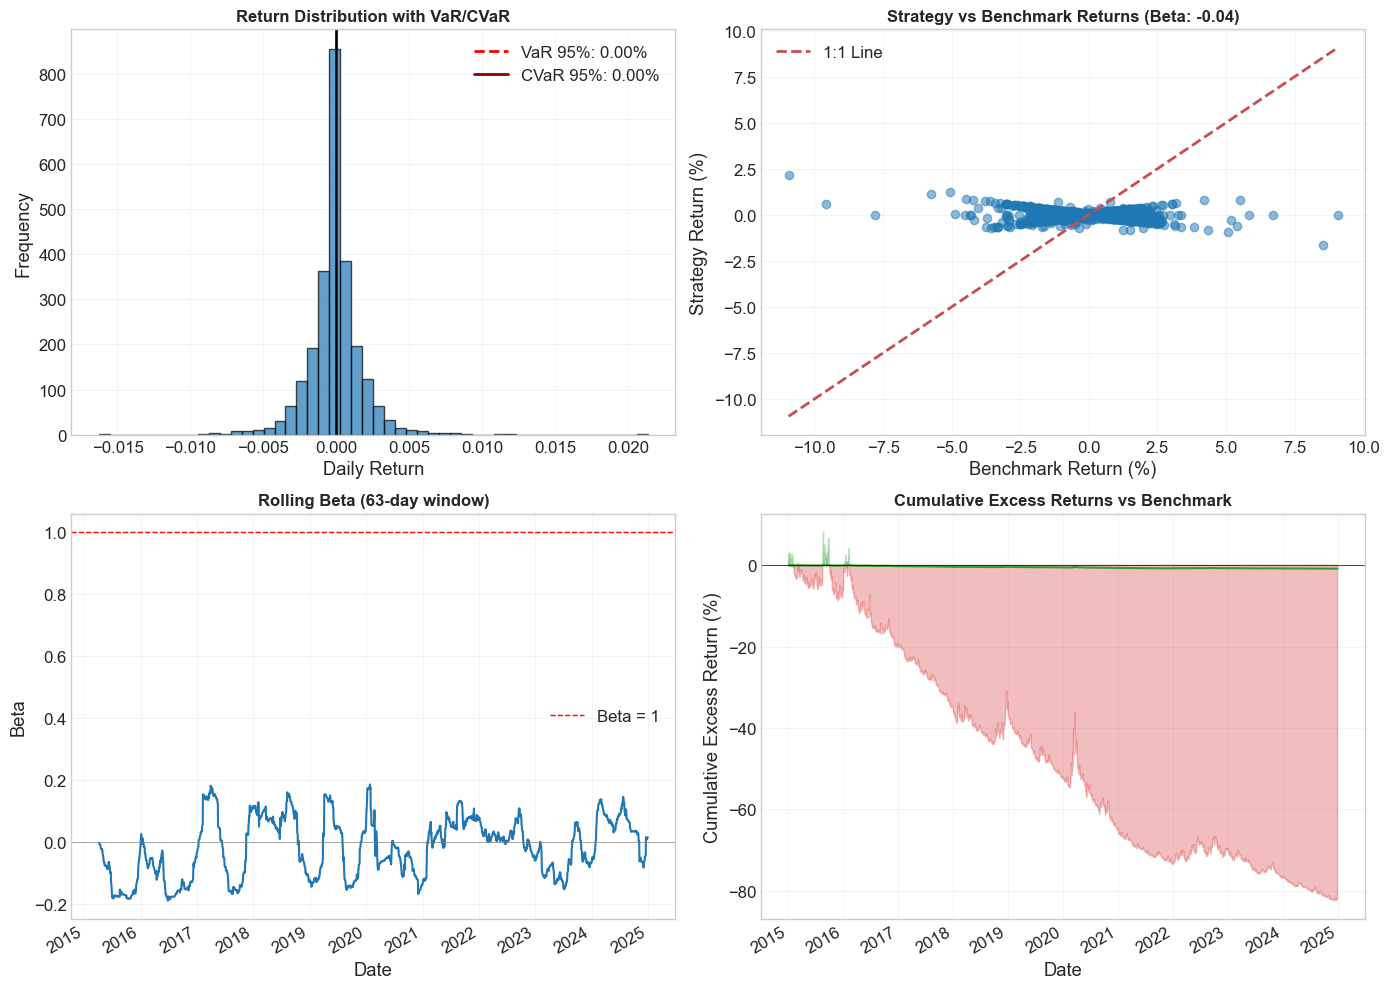

In [20]:
# Visualize risk metrics
if len(aligned_strategy) > 30 and "risk_metrics" in dir():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Return distribution with VaR/CVaR
    ax1 = axes[0, 0]
    aligned_strategy.hist(bins=50, ax=ax1, color="#1f77b4", alpha=0.7, edgecolor="black")
    var_95 = risk_metrics.get("var_95", 0)
    cvar_95 = risk_metrics.get("cvar_95", 0)
    ax1.axvline(
        x=var_95, color="red", linestyle="--", linewidth=2, label=f"VaR 95%: {var_95 * 100:.2f}%"
    )
    ax1.axvline(
        x=cvar_95,
        color="darkred",
        linestyle="-",
        linewidth=2,
        label=f"CVaR 95%: {cvar_95 * 100:.2f}%",
    )
    ax1.axvline(x=0, color="black", linestyle="-", linewidth=1)
    ax1.set_title("Return Distribution with VaR/CVaR", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Daily Return")
    ax1.set_ylabel("Frequency")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Strategy vs Benchmark scatter
    ax2 = axes[0, 1]
    ax2.scatter(aligned_benchmark * 100, aligned_strategy * 100, alpha=0.5, color="#1f77b4")
    ax2.plot(
        [aligned_benchmark.min() * 100, aligned_benchmark.max() * 100],
        [aligned_benchmark.min() * 100, aligned_benchmark.max() * 100],
        "r--",
        linewidth=2,
        label="1:1 Line",
    )
    beta = benchmark_metrics.get("beta", 1)
    ax2.set_title(
        f"Strategy vs Benchmark Returns (Beta: {beta:.2f})", fontsize=12, fontweight="bold"
    )
    ax2.set_xlabel("Benchmark Return (%)")
    ax2.set_ylabel("Strategy Return (%)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Rolling beta
    ax3 = axes[1, 0]
    window = CONFIG["risk"]["rolling_beta_window"]
    if len(aligned_strategy) > window:
        rolling_cov = aligned_strategy.rolling(window).cov(aligned_benchmark)
        rolling_var = aligned_benchmark.rolling(window).var()
        rolling_beta = rolling_cov / rolling_var
        rolling_beta.plot(ax=ax3, color="#1f77b4", linewidth=1.5)
        ax3.axhline(y=1, color="red", linestyle="--", linewidth=1, label="Beta = 1")
        ax3.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
        ax3.set_title(f"Rolling Beta ({window}-day window)", fontsize=12, fontweight="bold")
        ax3.set_xlabel("Date")
        ax3.set_ylabel("Beta")
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, "Insufficient data for rolling beta", ha="center", va="center")
        ax3.set_title("Rolling Beta (Insufficient Data)")

    # Cumulative excess returns
    ax4 = axes[1, 1]
    excess_returns = aligned_strategy - aligned_benchmark
    cumulative_excess = (1 + excess_returns).cumprod() - 1
    cumulative_excess.plot(ax=ax4, color="#2ca02c", linewidth=1.5)
    ax4.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax4.fill_between(
        cumulative_excess.index,
        0,
        cumulative_excess * 100,
        where=cumulative_excess >= 0,
        color="#2ca02c",
        alpha=0.3,
    )
    ax4.fill_between(
        cumulative_excess.index,
        0,
        cumulative_excess * 100,
        where=cumulative_excess < 0,
        color="#d62728",
        alpha=0.3,
    )
    ax4.set_title("Cumulative Excess Returns vs Benchmark", fontsize=12, fontweight="bold")
    ax4.set_xlabel("Date")
    ax4.set_ylabel("Cumulative Excess Return (%)")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [21]:
# Save results
output_dir = project_root / CONFIG["output"]["directory"]
output_dir.mkdir(exist_ok=True)

print(f"\nResults can be found in: {output_dir}")
print(f"\nBacktest completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Results can be found in: C:\Dev\projects\investment_trying\reports

Backtest completed at: 2026-05-01 15:29:10


## Notes

### Strategy Overview
The Multi-Pattern Strategy uses confluence scoring from 20 different pattern detectors:
- **Basic Patterns**: MSL, Matching Lows, NR7 Inside Day, N-Bar Decline, Floor Pivot
- **Harmonic Patterns**: Gartley, ABC, Symmetric Triangle, Donchian, Bollinger
- **Complex Patterns**: Cup Handle, Head Shoulders, Spike Ledge, Three Hills, Parabolic Arc
- **Classic Patterns**: Double Top, Double Bottom, Trader Vic 2B, Triple Top, Dead Cat Bounce

### Interpretation
- Signals are generated when multiple patterns agree (confluence)
- Market regime filter adapts to bull/bear/sideways conditions
- Position sizing based on ATR and risk parameters

### Next Steps
- Parameter optimization
- Walk-forward analysis
- Compare with other timeframes
- Add sector/market filters